# PRACTICA EVALUACIÓN FINAL - PARTE II #
Esta segunda parte supone el 25% restante de tarea práctica final del módulo de minería de datos. Junto con la parte 1, ambas puntúan el 60% de la nota final.

En esta parte 2 se pretende evaluar los conceptos relacionados con el analisis de series temporales y su aplicación a modelos de predicción.

Comenzando con esta parte de la práctica, en el primer bloque de código, conviene cargar las librerías que se van a utilizar a lo largo del notebook.

In [1]:
# importar librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import Holt
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pmdarima as pm

En el siguiente paso procedemos a cargar el fichero *Microsoft_Stock.csv* que servirá como conjunto de datos para llevar a cabo toda la evaluación de esta parte II. Se trata de un fichero en el que cada registro contiene para un día concreto datos de apertura, cierre, máximo, mínimo y volumen de cotización de las acciones de Microsoft en la bolsa de Nueva York. Se trata por tanto de un clásico problema de predicción de valores futuros. 

In [2]:
# Cargar el fichero de datos en un DataFrame

In [3]:
# Ruta al archivo
file_path = 'Microsoft_Stock.csv'

# Carga del dataset
df = pd.read_csv(file_path)

# Visualización rápida para verificar
print(df.head())

                Date   Open   High    Low  Close    Volume
0  4/1/2015 16:00:00  40.60  40.76  40.31  40.72  36865322
1  4/2/2015 16:00:00  40.66  40.74  40.12  40.29  37487476
2  4/6/2015 16:00:00  40.34  41.78  40.18  41.55  39223692
3  4/7/2015 16:00:00  41.61  41.91  41.31  41.53  28809375
4  4/8/2015 16:00:00  41.48  41.69  41.04  41.42  24753438


En los siguientes bloques de código el alumno debe programar las sentencias de código que considere oportunas para hacerse una idea general de los datos y de las variables. Visualización de datos, gráficos, etc. Los bloques son orientativos, el alumno puede añadir cuantos considere y codificarlos según su criterio.

In [4]:
# Mostrar los 10 primeros registros

In [5]:
df.head(10)

,Date,Open,High,Low,Close,Volume
0,4/1/2015 16:00:00,40.60,40.76,40.31,40.72,36865322
1,4/2/2015 16:00:00,40.66,40.74,40.12,40.29,37487476
2,4/6/2015 16:00:00,40.34,41.78,40.18,41.55,39223692
3,4/7/2015 16:00:00,41.61,41.91,41.31,41.53,28809375
4,4/8/2015 16:00:00,41.48,41.69,41.04,41.42,24753438
5,4/9/2015 16:00:00,41.25,41.62,41.25,41.48,25723861
6,4/10/2015 16:00:00,41.63,41.95,41.41,41.72,28022002
7,4/13/2015 16:00:00,41.40,42.06,41.39,41.76,30276692
8,4/14/2015 16:00:00,41.80,42.03,41.39,41.65,24244382
9,4/15/2015 16:00:00,41.76,42.46,41.68,42.26,27343581


In [6]:
# Describir el DataFrame

In [7]:
df.describe()

,Open,High,Low,Close,Volume
count,1511.000000,1511.000000,1511.000000,1511.000000,1.511000e+03
mean,107.385976,108.437472,106.294533,107.422091,3.019863e+07
std,56.691333,57.382276,55.977155,56.702299,1.425266e+07
min,40.340000,40.740000,39.720000,40.290000,1.016120e+05
25%,57.860000,58.060000,57.420000,57.855000,2.136213e+07
50%,93.990000,95.100000,92.920000,93.860000,2.662962e+07
75%,139.440000,140.325000,137.825000,138.965000,3.431962e+07
max,245.030000,246.130000,242.920000,244.990000,1.352271e+08


In [8]:
# Mostrar las columnas y tipos de datos

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1511 entries, 0 to 1510
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1511 non-null   str    
 1   Open    1511 non-null   float64
 2   High    1511 non-null   float64
 3   Low     1511 non-null   float64
 4   Close   1511 non-null   float64
 5   Volume  1511 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 71.0 KB


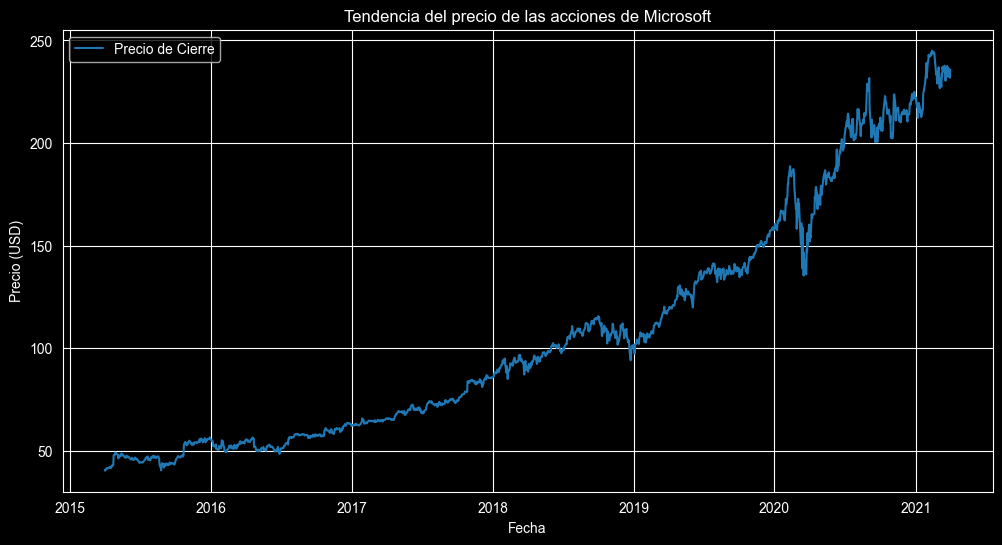

In [10]:
# Convetir la fecha que esta en str a formato date
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])

plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Close'], label='Precio de Cierre', color='tab:blue')
plt.title('Tendencia del precio de las acciones de Microsoft')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid(True)
plt.show()

Se ha de filtrar la serie quedandose solo con los datos desde el año 2020 (incluido) en adelante. Una vez filtrada, mostrar la serie temporal de la variable ***Close*** en un gráfico de línea.

In [11]:
# Filtrar datos desde 2020

In [12]:
df_filtered = df[df['Date'] >= '2020-01-01'].copy()

In [13]:
# Verificamos los resultados
print(f"Registros totales: {len(df)}")
print(f"Registros desde 2020: {len(df_filtered)}")
print(df_filtered.head())

Registros totales: 1511
Registros desde 2020: 314
                    Date    Open    High     Low   Close    Volume
1197 2020-01-02 16:00:00  158.78  160.73  158.33  160.62  22634546
1198 2020-01-03 16:00:00  158.32  159.95  158.06  158.62  21121681
1199 2020-01-06 16:00:00  157.08  159.10  156.51  159.03  20826702
1200 2020-01-07 16:00:00  159.32  159.67  157.32  157.58  21881740
1201 2020-01-08 16:00:00  158.93  160.80  157.95  160.09  27762026


### Pregunta 1 ###
En primera instancia echando un vistazo a la serie en la gráfica, ¿Qué pinta tiene la serie en cuanto a estacionariedad? Describe brevemente las impresiones acerca de porque parece que la serie es o no estacionaria.

***Respuesta:***

La serie no es estacionaria.

La estacionariedad exige que la media y la varianza se mantengan constantes en el tiempo, y aquí no se cumple ninguna de las dos condiciones. Tendencia: en el periodo analizado (enero de 2020 a marzo de 2021) el precio de cierre pasa de niveles en torno a 160 USD a superar los 240 USD, de modo que la media se desplaza claramente al alza. Varianza: la amplitud de las oscilaciones no es homogénea; destaca la caída abrupta de marzo de 2020 y la mayor volatilidad de los meses posteriores. Dependencia temporal: cada valor está muy próximo al del día anterior, un comportamiento típico de un proceso con raíz unitaria más que de una serie que fluctúe alrededor de un nivel fijo.

A continuación pasamos a analizar desde un punto de vista más formal la estacionariedad de la serie. En primer lugar calcular las funciones de autocorrelación y autocorrelación parcial y mostrar las gráficas con ambas funciones.

In [14]:
# Gráfica ACF

In [15]:
# Gráfica PACF

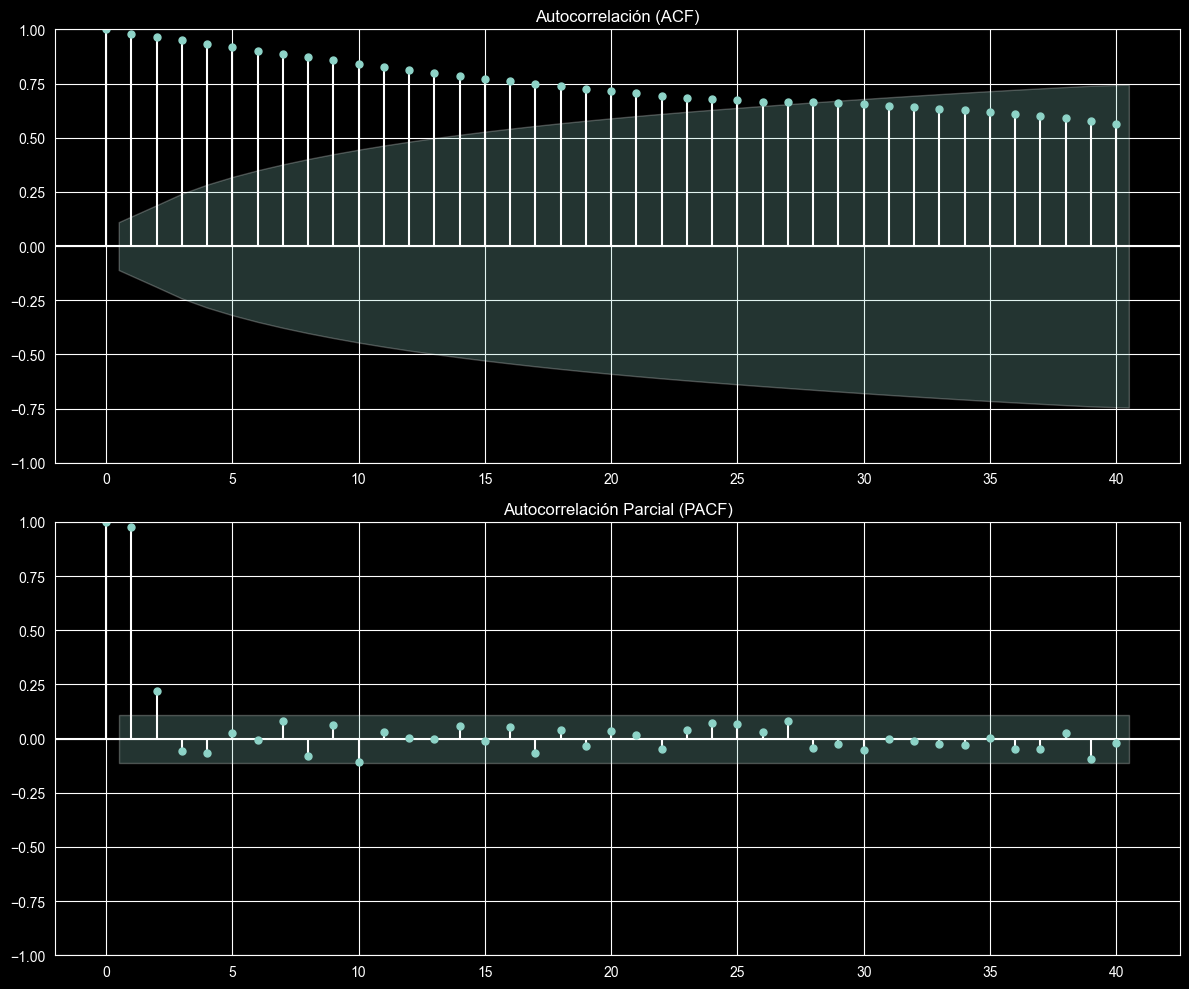

In [16]:

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Gráfica ACF
plot_acf(df_filtered['Close'], ax=ax1, lags=40)
ax1.set_title('Autocorrelación (ACF)')

# Gráfica PACF
plot_pacf(df_filtered['Close'], ax=ax2, lags=40, method='ywm')
ax2.set_title('Autocorrelación Parcial (PACF)')

plt.tight_layout()
plt.show()

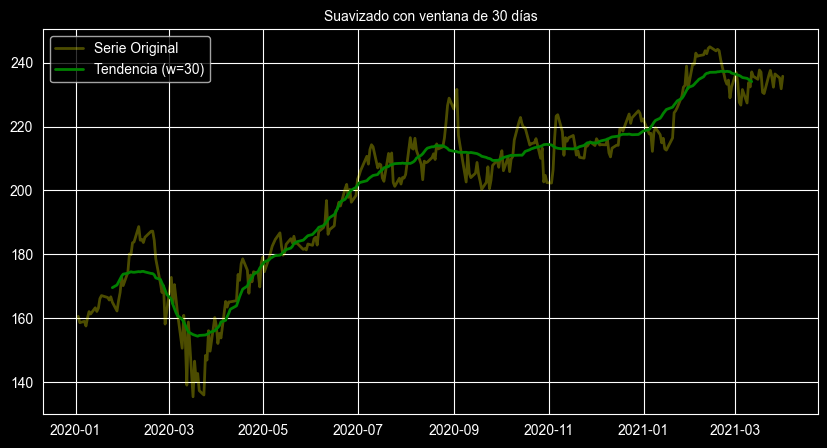

In [17]:
# Ventana 30
df_filtered['trend_30'] = df_filtered['Close'].rolling(window=30, center=True).mean()

plt.figure(figsize=(10, 5))
plt.plot(df_filtered['Date'], df_filtered['Close'], label="Serie Original", color='yellow', alpha=0.3, linewidth=2)
plt.plot(df_filtered['Date'], df_filtered['trend_30'], label="Tendencia (w=30)", color='green', linewidth=2)
plt.title("Suavizado con ventana de 30 días", fontsize=10)
plt.legend()
plt.show()

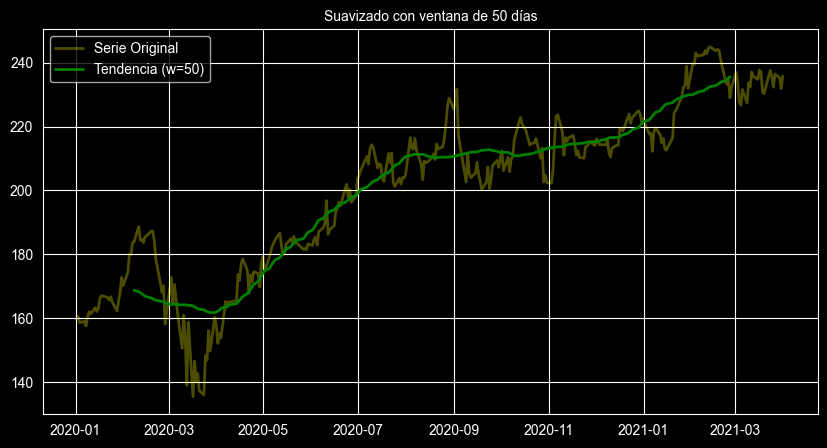

In [18]:
# Ventana 50
df_filtered['trend_50'] = df_filtered['Close'].rolling(window=50, center=True).mean()

plt.figure(figsize=(10, 5))
plt.plot(df_filtered['Date'], df_filtered['Close'], label="Serie Original", color='yellow', alpha=0.3, linewidth=2)
plt.plot(df_filtered['Date'], df_filtered['trend_50'], label="Tendencia (w=50)", color='green', linewidth=2)
plt.title("Suavizado con ventana de 50 días", fontsize=10)
plt.legend()
plt.show()

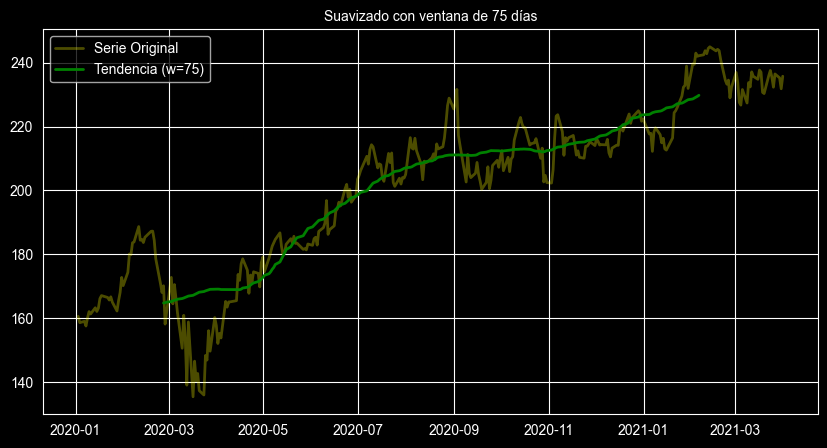

In [19]:
# Ventana 75
df_filtered['trend_75'] = df_filtered['Close'].rolling(window=75, center=True).mean()

plt.figure(figsize=(10, 5))
plt.plot(df_filtered['Date'], df_filtered['Close'], label="Serie Original", color='yellow', alpha=0.3, linewidth=2)
plt.plot(df_filtered['Date'], df_filtered['trend_75'], label="Tendencia (w=75)", color='green', linewidth=2)
plt.title("Suavizado con ventana de 75 días", fontsize=10)
plt.legend()
plt.show()

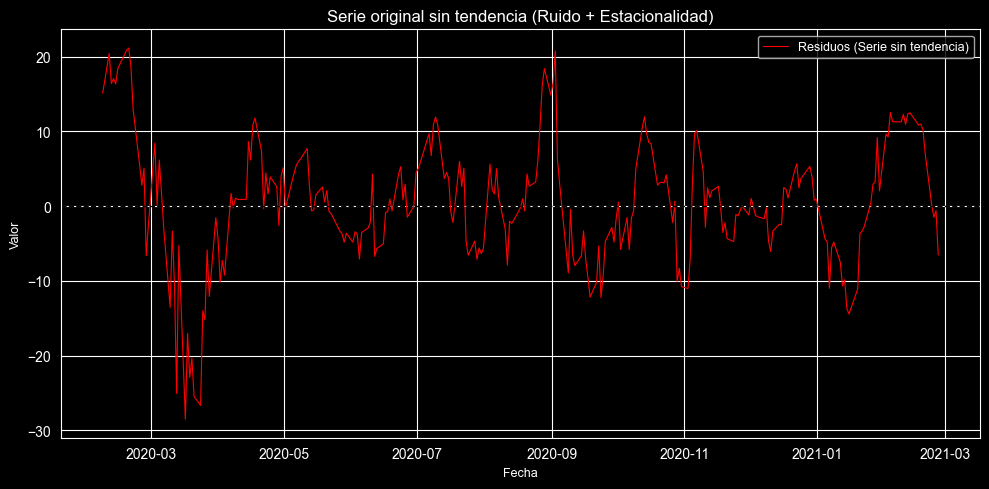

In [20]:
#original sin tendencia
trend_50 = df_filtered['Close'].rolling(window=50, center=True).mean()
deseasonalized = df_filtered['Close'] - trend_50

plt.figure(figsize=(10, 5))
plt.plot(df_filtered['Date'], deseasonalized, label="Residuos (Serie sin tendencia)", color='red', linewidth=0.8)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title("Serie original sin tendencia (Ruido + Estacionalidad)", fontsize=12)
plt.xlabel("Fecha", fontsize=9)
plt.ylabel("Valor", fontsize=9)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Pregunta 2 ###
A la vista de las 2 gráficas de autocorrelación, ¿Se aprecian signos de estacionariedad en la serie? ¿Por qué? ¿Se aprecian signos de estacionalidad? ¿Por qué?

***Respuesta:***

Estacionariedad. La serie no es estacionaria. En la ACF los coeficientes se mantienen próximos a 1 durante muchos rezagos y decaen de forma muy lenta y casi lineal, patrón característico de una serie con tendencia. En una serie estacionaria la autocorrelación caería rápidamente hacia cero en unos pocos rezagos. La PACF lo confirma: presenta un único pico muy elevado en el rezago 1 y valores no significativos a partir de ahí, lo que indica que toda la dependencia se explica por el valor inmediatamente anterior, como en un paseo aleatorio.

Estacionalidad. No se aprecian signos de estacionalidad. Para que la hubiera, la ACF debería mostrar picos que reaparecieran a intervalos regulares y fijos, y no es el caso: el decaimiento es monótono, sin repuntes periódicos. Esto es lo esperable en una serie diaria de precios de cotización, donde no existe un ciclo de periodo fijo comparable al mensual o trimestral de una serie de ventas. Las oscilaciones que se observan al eliminar la tendencia son irregulares en amplitud y en duración, por lo que corresponden a la volatilidad propia del activo y no a un componente estacional.

Ahora mediante un test de Dickey Fuller aumentado, realizamos la última comprobación de estacionariedad de la serie.

In [21]:
# Test de Dickey Fuller Aumentado

In [22]:
from statsmodels.tsa.stattools import adfuller

# Ejecutamos el test ADF
result = adfuller(df_filtered['Close'].dropna())

print('ADF Statistic:', result[0])
print('p-value:', result[1])

if result[1] < 0.05:
    print("La serie es estacionaria (rechazamos la hipótesis nula) ")
else:
    print("La serie NO es estacionaria (aceptamos la hipotesis nula")

ADF Statistic: -1.4029588977517973
p-value: 0.5808567665335312
La serie NO es estacionaria (aceptamos la hipotesis nula


In [23]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Se emplea un periodo de 63 observaciones, que equivale aproximadamente al número
# de sesiones bursátiles de un trimestre natural. No se asume que exista un ciclo
# trimestral real: la descomposición se usa aquí como herramienta para aislar la
# tendencia y comprobar formalmente su efecto sobre la estacionariedad.
periodo_ajustado = 63

# Descomposición Multiplicativa
result_mult = seasonal_decompose(df_filtered['Close'], model='multiplicative', period=periodo_ajustado)
residuo_mult = result_mult.resid.dropna()

# Descomposición Aditiva
result_add = seasonal_decompose(df_filtered['Close'], model='additive', period=periodo_ajustado)
residuo_add = result_add.resid.dropna()

# Función para el test ADF
def test_adf(serie, nombre):
    print(f"\nTest ADF para: {nombre} ")
    res = adfuller(serie)
    print(f'p-value: {res[1]:.4f}')
    if res[1] < 0.05:
        print("Resultado: Es estacionaria")
    else:
        print("Resultado: NO es estacionaria")

# Ejecución de los tests
test_adf(df_filtered['Close'], "Serie Original")
test_adf(residuo_add, "Residuo (Modelo Aditivo)")
test_adf(residuo_mult, "Residuo (Modelo Multiplicativo)")


Test ADF para: Serie Original 
p-value: 0.5809
Resultado: NO es estacionaria

Test ADF para: Residuo (Modelo Aditivo) 
p-value: 0.0002
Resultado: Es estacionaria

Test ADF para: Residuo (Modelo Multiplicativo) 
p-value: 0.0004
Resultado: Es estacionaria


### Pregunta 3 ###
Según el test realizado, ¿es estacionaria la serie?

***Respuesta:***

Según el test de Dickey-Fuller aumentado, la serie original no es estacionaria: el p-valor es 0.5809, muy por encima de 0.05, de modo que no se puede rechazar la hipótesis nula de existencia de raíz unitaria. El estadístico ADF es de -1.4030, lejos de los valores críticos.

Al aplicar el test sobre el residuo de la descomposición, ya sea aditiva (p = 0.0002) o multiplicativa (p = 0.0004), sí se rechaza la hipótesis nula y la serie resultante es estacionaria. Conviene precisar a qué se debe esta mejora: la descomposición elimina simultáneamente tendencia y componente estacional, pero, como se concluyó en P2, esta serie no presenta estacionalidad. La ganancia proviene por tanto de la extracción de la tendencia, que es el único factor responsable de la no estacionariedad.

En consecuencia, para modelizar la serie basta con aplicar una diferenciación de primer orden, que es precisamente la transformación que se emplea en los apartados siguientes.

Seguimos con el analisis y para ello vamos a tratar de modelar la serie con un suavizado exponencial y predecir con este modelo algunos de los puntos finales de la serie. En primer lugar, el alumno debe escoger, teniendo en cuenta lo aprendido en el analisis realizado hasta aquí, el modelo adecuado de suavizado exponencial. A continuación, utilizará todos los datos excepto los 30 últimos días de la serie, y modelará el suavizado con dichos datos. Con este modelo, debe predecir los 30 valores restantes y por último, debe mostrar en una misma gráfica: la serie original en un color hasta el punto donde comienzan los datos de validación (30 últimos puntos), los 30 últimos puntos de la serie original en otro color y, por último, en un tercer color, los puntos predichos por el modelo de suavizado.

In [24]:
# Separar en conjunto de entrenamiento y validación

In [25]:
from statsmodels.tsa.holtwinters import Holt
train = df_filtered['Close'].iloc[:-30]
test = df_filtered['Close'].iloc[-30:]

In [26]:
# Crear y ajustar el modelo de suavizado escogido

In [27]:
model = Holt(train, initialization_method="estimated").fit()

In [28]:
# Predecir los datos validación

In [29]:
predictions = model.forecast(30)

In [30]:
# Mostrar en gráfico los resultados y la serie original.

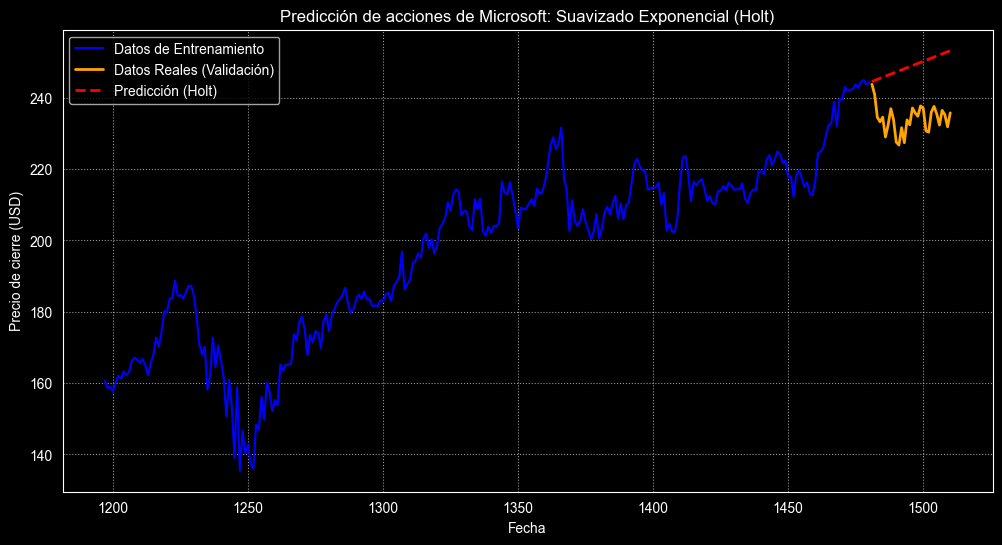

In [31]:
#Mostrar resultados en gráfico
plt.figure(figsize=(12, 6))

# Serie de entrenamiento
plt.plot(train.index, train, label="Datos de Entrenamiento", color='blue', linewidth=1.5)

# Serie original (validación)
plt.plot(test.index, test, label="Datos Reales (Validación)", color='orange', linewidth=2)

# Predicciones
plt.plot(test.index, predictions, label="Predicción (Holt)", color='red', linestyle='--', linewidth=2)

plt.title("Predicción de acciones de Microsoft: Suavizado Exponencial (Holt)", fontsize=12)
plt.xlabel("Fecha", fontsize=10)
plt.ylabel("Precio de cierre (USD)", fontsize=10)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### Pregunta 4 ###
¿Qué tipo de suavizado exponencial se ha empleado y por qué?

***Respuesta:***

Se ha utilizado el modelo de **Suavizado Exponencial Lineal de Holt**.

La elección se basa en la estructura de la serie:
* **Tendencia:** el modelo incluye un componente de tendencia, lo que permite capturar el crecimiento sostenido observado en los datos.
* **Sin estacionalidad:** no incorpora componente estacional, lo cual es adecuado ya que no se observan patrones cíclicos claros.
* **Comportamiento de la predicción:** la proyección sigue la tendencia general de la serie, suavizando la volatilidad.

En resumen, se elige el modelo de Holt porque la serie presenta tendencia y no muestra estacionalidad evidente, por lo que es suficiente para representar su comportamiento.


Pasamos ahora a entrenar un modelo autoregresivo para, de nuevo, predecir los 30 últimos valores. En este caso, si en puntos anteriores de esta práctica se hubiera determinado que la serie no es estacionaria, se debe convertir en estacionaria y comprobar que efectivamente lo es después de la transformación. Una vez que sea estacionaria, se ha de seleccionar en base a la función de autocorrelación (ACF) y/o la autocorrelación parcial (PACF) el orden adecuado del modelo autoregresivo (AR).

In [32]:
# Transformar la serie en estacionaria en caso de que no lo fuera

In [33]:
df_filtered['Close_diff'] = df_filtered['Close'].diff().dropna()

In [34]:
# Comprobación de estacionariedad

In [35]:
result = adfuller(df_filtered['Close_diff'].dropna())
print(f'p-value tras diferenciar: {result[1]:.4f}')

if result[1] < 0.05:
    print("La serie ahora es estacionaria.")
else:
    print("La serie aún no es estacionaria.")

p-value tras diferenciar: 0.0000
La serie ahora es estacionaria.


In [36]:
# Mostrar la función de autocorrelación y autocorrelación parcial

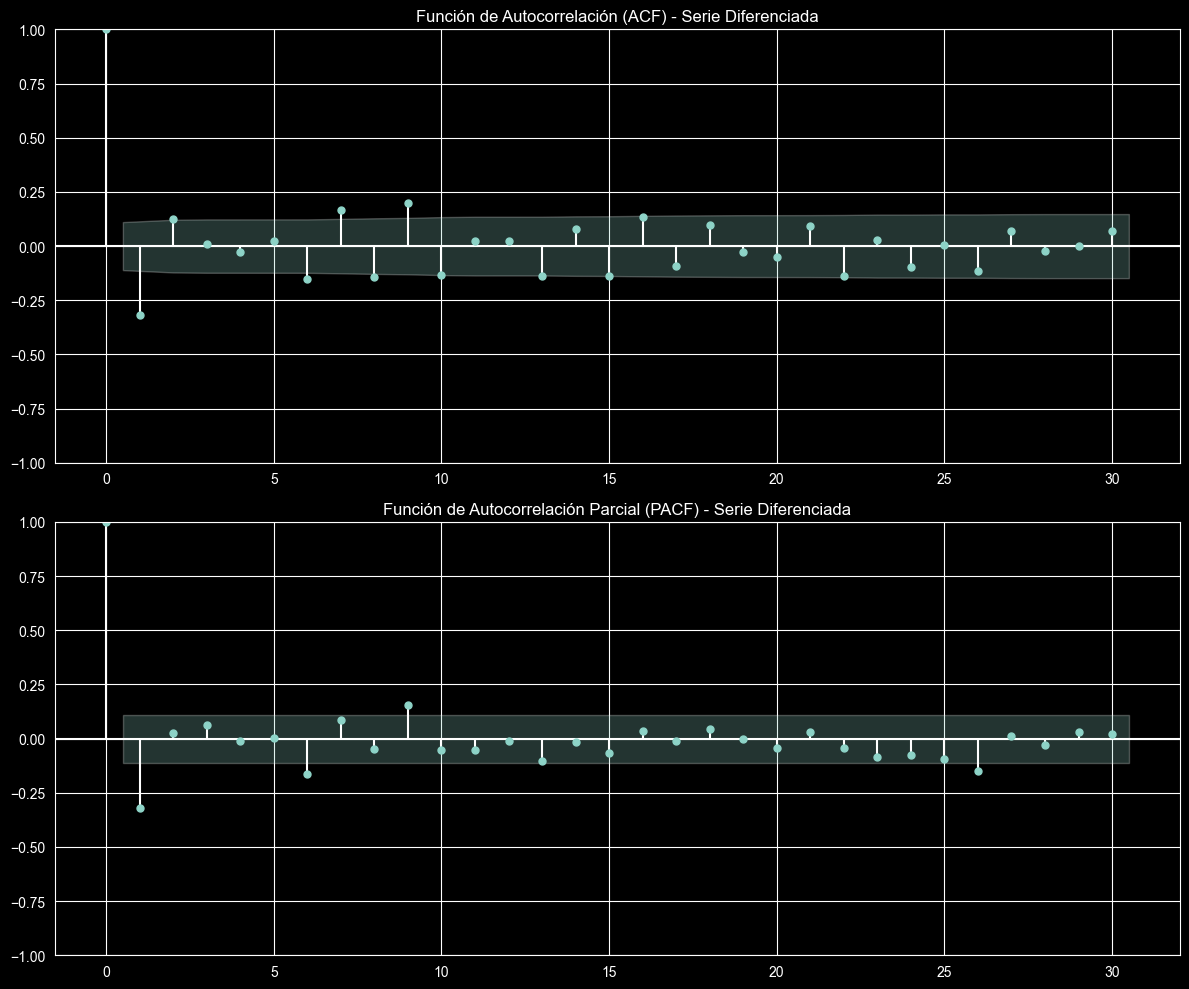

In [37]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# ACF
plot_acf(df_filtered['Close_diff'].dropna(), ax=ax1, lags=30)
ax1.set_title('Función de Autocorrelación (ACF) - Serie Diferenciada')

# PACF
plot_pacf(df_filtered['Close_diff'].dropna(), ax=ax2, lags=30, method='ywm')
ax2.set_title('Función de Autocorrelación Parcial (PACF) - Serie Diferenciada')

plt.tight_layout()
plt.show()

### Pregunta 5 ###
¿Cual es el orden del modelo autoregresivo que se ha seleccionado y por qué?

***Respuesta:***

En la gráfica de la **PACF** se observa un único pico significativo en el rezago 1, que se sale de las bandas de confianza. A partir de ahí, los demás rezagos no son significativos.

Según la metodología de **Box-Jenkins**, esto indica que el orden autorregresivo es **p = 1**, ya que la PACF “corta” después del primer rezago. Es decir, el valor actual depende principalmente del valor inmediatamente anterior.

En resumen, se elige **p = 1** porque solo el primer rezago aporta información relevante en la dependencia temporal de la serie.


Una vez escogido el orden del modelo autorregresivo, pasamos a entrenar el modelo y a predecir los 30 últimos valores. Por tanto lo primero será, como en ejercicios anteriores, separar por un lado la serie original transformada en estacionaria en caso de que no lo fuera, y eso si, quitandole los últimos 30 puntos. Una vez entrenado, se ha de mostrar el resumen de los parametros del modelo, coeficientes y demás métricas habituales. A continuación, utilizar el modelo para predecir los últimos 30 valores y mostrarlos en un gráfico de lineas junto con la serie original. Antes de pintarlos, en caso de que la serie original haya sido transformada para convertirla en estacionaria, será necesario deshacer las transformaciones de los valores predichos y, ahora si, pintarla junto con los valores de la serie original.

In [38]:
# Separar en conjunto de entrenamiento y validación

In [39]:
# Trabajamos sobre la serie diferenciada
train_set = df_filtered['Close_diff'].dropna().iloc[:-30].reset_index(drop=True)
test_real = df_filtered['Close'].iloc[-30:] # Guardamos los reales para comparar al final

In [40]:
# Crear y ajustar el modelo autorregresivo del orden escogido

In [41]:
from statsmodels.tsa.ar_model import AutoReg

p = 1
model_ar = AutoReg(train_set, lags=p).fit()

In [42]:
# Mostrar el resumen de los parametros y resultados del entrenamiento del modelo

In [43]:
print(model_ar.summary())

                            AutoReg Model Results                             
Dep. Variable:             Close_diff   No. Observations:                  283
Model:                     AutoReg(1)   Log Likelihood                -817.444
Method:               Conditional MLE   S.D. of innovations              4.392
Date:                Wed, 29 Jul 2026   AIC                           1640.888
Time:                        17:24:55   BIC                           1651.813
Sample:                             1   HQIC                          1645.269
                                  283                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.4016      0.262      1.532      0.125      -0.112       0.915
Close_diff.L1    -0.3329      0.056     -5.932      0.000      -0.443      -0.223
                                    Root

Test de Ljung-Box sobre los residuos:
    lb_stat  lb_pvalue
5    2.7599     0.7369
10  19.4189     0.0353
20  31.4642     0.0494

Jarque-Bera: 68.00  (p = 0.0000)
Media de los residuos: 0.0000  |  Desv. típica: 4.3999


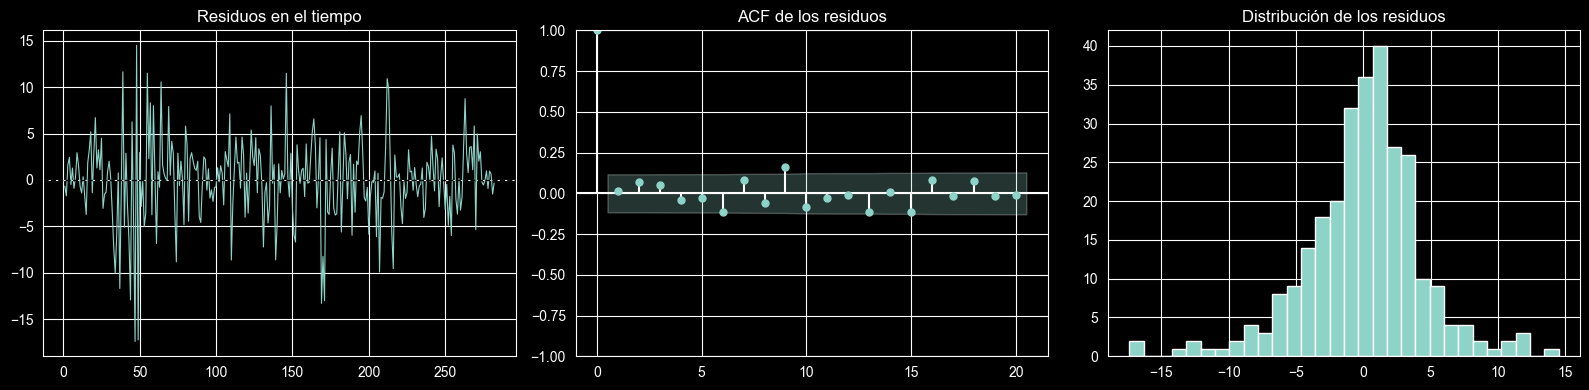

In [44]:
# ── DIAGNÓSTICO DE RESIDUOS DEL MODELO AR(1) ──────────────────────────────────
resid = model_ar.resid

# Test de Ljung-Box: H0 = no hay autocorrelación en los residuos
lb = acorr_ljungbox(resid, lags=[5, 10, 20], return_df=True)
print('Test de Ljung-Box sobre los residuos:')
print(lb.round(4))

# Test de normalidad
from scipy.stats import jarque_bera
jb_stat, jb_p = jarque_bera(resid)
print(f'\nJarque-Bera: {jb_stat:.2f}  (p = {jb_p:.4f})')
print(f'Media de los residuos: {resid.mean():.4f}  |  Desv. típica: {resid.std():.4f}')

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].plot(resid, linewidth=0.8)
ax[0].axhline(0, color='black', linestyle='--', linewidth=1)
ax[0].set_title('Residuos en el tiempo')
plot_acf(resid, lags=20, ax=ax[1])
ax[1].set_title('ACF de los residuos')
ax[2].hist(resid, bins=30, edgecolor='white')
ax[2].set_title('Distribución de los residuos')
plt.tight_layout()
plt.show()

In [45]:
# Predecir los últimos 30 valores utilizando el modelo entrenado

In [46]:
predictions1 = model_ar.fittedvalues

In [47]:
# Deshacer las transformaciones sobre los valores predichos

In [48]:
predictions_diff = model_ar.predict(start=len(train_set), end=len(train_set) + 29)

# Usamos último valor conocido de la serie real (índice -31)
last_known_price = df_filtered['Close'].iloc[-31]

# Reconstruimos usando suma acumulada
predictions_final = last_known_price + predictions_diff.cumsum()

In [49]:
# Mostrar en gráfica la serie original y los valores predichos

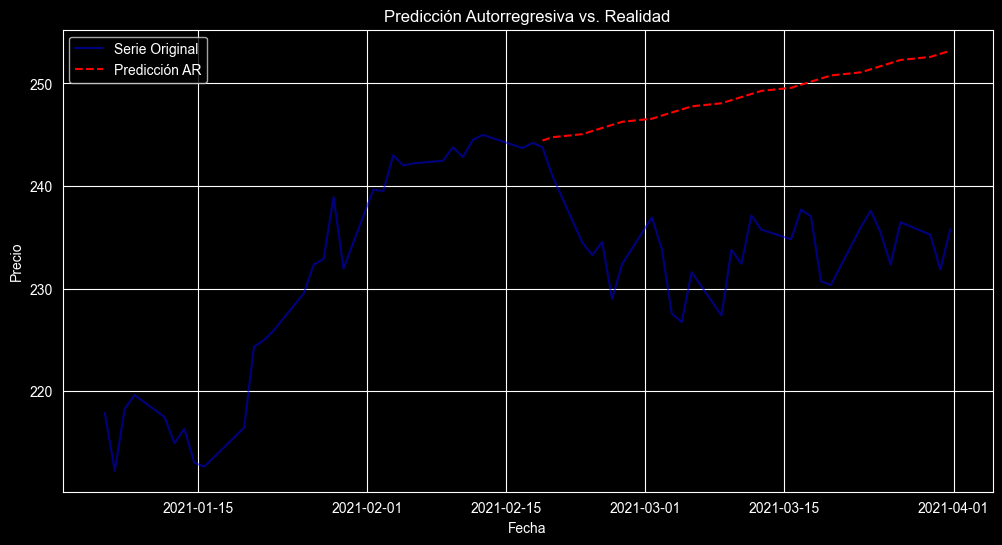

In [50]:
plt.figure(figsize=(13, 6))

plt.plot(df_filtered['Date'], df_filtered['Close'],
         label='Serie real', color='#1f4e79', linewidth=1.2)

plt.plot(df_filtered['Date'].iloc[-30:], forecast_sin_deriva,
         label='ARIMA(1,1,0) sin deriva', color='red', linestyle='--', linewidth=1.8)

plt.plot(df_filtered['Date'].iloc[-30:], forecast_deriva,
         label='ARIMA(1,1,0) con deriva', color='darkorange', linestyle=':', linewidth=1.8)

plt.axvline(df_filtered['Date'].iloc[-31], color='gray', linestyle='-.',
            linewidth=1, alpha=0.7)

plt.title('Predicción ARIMA a 30 días: efecto del término de deriva',
          fontsize=13, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Precio de cierre (USD)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

### Pregunta 6 ###
A la vista de los resultados obtenidos en el entrenamiento del modelo, ¿qué podemos decir de los residuos y por tanto de la validez estadística del modelo?. En cuanto a la pinta que tiene el resultado final visualizado en el gráfico, ¿Qué conclusiones podemos sacar sobre el modelo? ¿es adecuado para predecir valores futuros de la serie? ¿De qué manera influye en esta valoración el hecho de que hayamos seleccionado para validar los últimos 30 puntos con respecto a la pinta que tendría si solo hubieran sido los últimos 20?

***Respuesta:***

**Residuos.** El AR(1) elimina la autocorrelación de corto plazo (Ljung-Box, rezago 5: p = 0.7369), aunque persiste una autocorrelación marginal en los rezagos 10 y 20 (p = 0.0353 y 0.0494), lo que sugiere cierta estructura temporal no capturada. Los residuos tienen media 0 y no muestran patrones claros, pero el test de Jarque-Bera (p = 0.0000) rechaza la normalidad, indicando colas pesadas típicas de series financieras.

**Coeficientes.** El coeficiente de `Close_diff.L1` (-0.3329; p < 0.001) indica reversión parcial a la media. La raíz AR (>1) confirma estacionariedad. La constante no es significativa (p = 0.125), por lo que la deriva ascendente de la predicción carece de respaldo estadístico.

**Resultado gráfico.** La predicción a 30 días es casi lineal porque un AR(1) sobre la serie diferenciada converge rápidamente a su media. El modelo no reproduce la corrección ni la volatilidad observadas en la serie real.

**Horizonte de validación.** Un horizonte más corto (p. ej., 20 días) produciría un ajuste visual mejor al acumular menos error, aunque el modelo no sería realmente más preciso.

**Conclusión.** El modelo captura la dependencia de corto plazo, pero no es adecuado para pronósticos a 30 días, ya que deja autocorrelación residual, proyecta una tendencia basada en una constante no significativa y no modeliza la volatilidad.


Por último, el alumno debe optimizar el modelo, cambiando el orden de las componentes AR, I y MA del modelo ARIMA, hasta llegar a una combinación que mejore el anterior modelo y que pueda ser incluso utilizable para predecir valores futuros de la serie. Para ello puede optar por realizarlo de forma manual probando distintas combinaciones o mediante algún algoritmo automático que encuentre la mejor combinación de ordenes para el modelo.

In [51]:
# Para el método manual, evaluar la ACF y PACF de la serie estacionaria (transformada si fuera necesario)

In [52]:
# Encontrar los ordenes p y q adecuados para las partes AR y MA

In [53]:
# La selección de órdenes se realiza SOLO con el conjunto de entrenamiento.
# Ajustarla sobre la serie completa dejaría que los 30 días de validación
# influyeran en la elección del modelo (fuga de información).
train_ts = df_filtered['Close'].iloc[:-30]

model_arima = pm.auto_arima(
    train_ts,
    d=1,                 # la diferenciación de orden 1 quedó justificada por el ADF
    seasonal=False,      # en P2 se descartó la existencia de componente estacional
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
)

print(model_arima.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1649.417, Time=0.09 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1677.208, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1646.045, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1652.040, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1676.346, Time=0.01 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=1647.451, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1647.649, Time=0.02 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=1648.904, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=1646.327, Time=0.01 sec

Best model:  ARIMA(1,1,0)(0,0,0)[0] intercept
Total fit time: 0.249 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  284
Model:               SARIMAX(1, 1, 0)   Log Likelihood                -820.022
Date:                Wed, 29 Jul 2026   AIC      

In [54]:
# Aplicar el modelo ARIMA incluyendo los ordenes p y q, pero además incluyendo el orden de diferenciación d

In [55]:
from statsmodels.tsa.arima.model import ARIMA

# Sustituye p, d, q por los valores que te haya dado el auto_arima
p, d, q = 1, 1, 0
model = ARIMA(df_filtered['Close'].iloc[:-30], order=(p, d, q))
model_fit = model.fit()

# Predicción
forecast = model_fit.forecast(steps=30)

In [56]:
# Predecir y pintar los resultados como en puntos anteriores

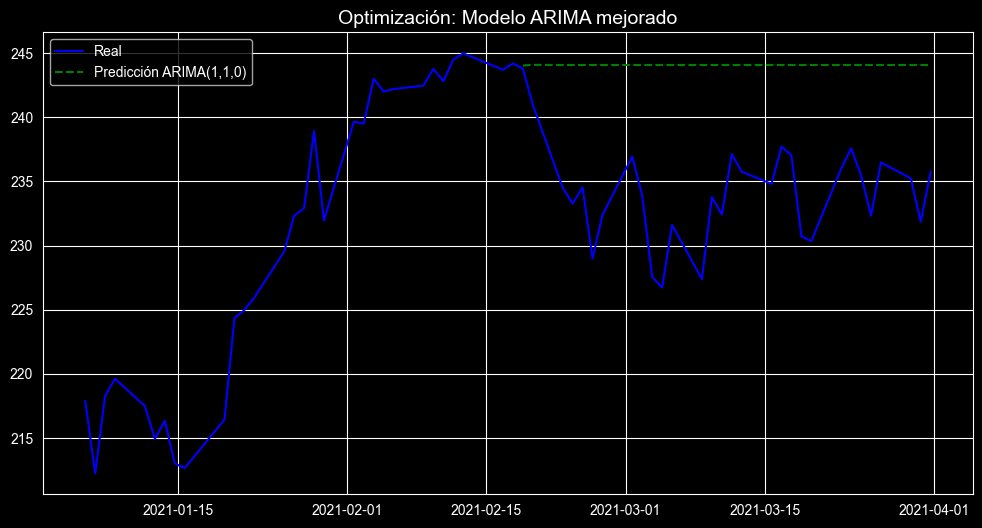

In [57]:
plt.figure(figsize=(12, 6))
plt.plot(df_filtered['Date'].iloc[-60:], df_filtered['Close'].iloc[-60:], label="Real", color='blue')
plt.plot(df_filtered['Date'].iloc[-30:], forecast, label=f"Predicción ARIMA({p},{d},{q})", color='green', linestyle='--')
plt.title("Optimización: Modelo ARIMA mejorado", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

In [58]:
# ── COMPARATIVA CUANTITATIVA SOBRE LOS 30 DÍAS DE VALIDACIÓN ──────────────────
real = df_filtered['Close'].iloc[-30:].values

# Baseline naive: predecir que el precio se mantiene en el último valor conocido.
# Es la referencia obligada en series financieras: si un modelo no lo supera,
# no aporta valor predictivo.
naive = np.full(30, df_filtered['Close'].iloc[-31])

candidatos = {
    'Naive (último valor)': naive,
    'Holt (suavizado exponencial)': predictions.values,
    'AR(1) sobre serie diferenciada': predictions_final.values,
    f'ARIMA({p},{d},{q})': forecast.values,
}

comparativa = pd.DataFrame([
    {
        'Modelo': nombre,
        'RMSE': mean_squared_error(real, pred) ** 0.5,
        'MAE': mean_absolute_error(real, pred),
        'MAPE (%)': np.mean(np.abs((real - pred) / real)) * 100,
    }
    for nombre, pred in candidatos.items()
]).sort_values('RMSE')

print(comparativa.round(3).to_string(index=False))

                        Modelo   RMSE    MAE  MAPE (%)
                  ARIMA(1,1,0) 10.665  9.977     4.289
          Naive (último valor) 10.780 10.101     4.342
AR(1) sobre serie diferenciada 15.438 14.720     6.316
  Holt (suavizado exponencial) 15.482 14.772     6.338


### Pregunta 7 ###
Hacer una interpretación libre del modelo entrenado y de los resultados obtenidos. ¿Sería utilizable para predicción de valores futuros de la serie temporal?

***Respuesta:***

**Modelo seleccionado.** La búsqueda *stepwise* seleccionó un ARIMA(1,1,0) por presentar el menor AIC (1646.045). La diferenciación elimina la tendencia y el término AR(1) captura la dependencia de corto plazo. La selección se realizó únicamente con los datos de entrenamiento, por lo que el conjunto de validación no influyó en la elección del modelo.

**Coeficientes.** El coeficiente AR(1) (-0.3321; p < 0.001) confirma una reversión parcial a la media. El intercepto no es significativo (p = 0.139), por lo que la deriva ascendente proyectada carece de respaldo estadístico. Los resultados son prácticamente idénticos al modelo AR(1).

**Diagnóstico.** El test de Ljung-Box (p = 0.81) no detecta autocorrelación residual. Sin embargo, Jarque-Bera (p < 0.001) rechaza la normalidad y el test de heterocedasticidad (p < 0.001) confirma una varianza no constante, con mayor volatilidad al inicio de la muestra.

**Capacidad predictiva.** En la validación de 30 días, el ARIMA obtuvo un RMSE de 10.665 (MAE = 9.977; MAPE = 4.29%), mejor que el AR(1) y Holt. No obstante, la mejora frente al baseline de persistencia (RMSE = 10.780) fue de solo un 1.1%, una diferencia sin relevancia práctica.

**Conclusión.** El ARIMA(1,1,0) es estadísticamente consistente, pero no resulta útil para predecir niveles a 30 días, ya que la serie se comporta como un paseo aleatorio. La principal estructura restante está en la volatilidad, por lo que modelos GARCH serían más adecuados para modelizar el riesgo que el precio.
